In [1]:
from google.colab import files
uploaded = files.upload()

Saving digital_marketing_campaign_dataset.csv to digital_marketing_campaign_dataset.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('digital_marketing_campaign_dataset.csv')
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [5]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Income,0
CampaignChannel,0
CampaignType,0
AdSpend,0
ClickThroughRate,0
ConversionRate,0
WebsiteVisits,0


In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(8000, 20)

In [9]:
df['Conversion'].value_counts()

,count
Conversion,
1,7012
0,988


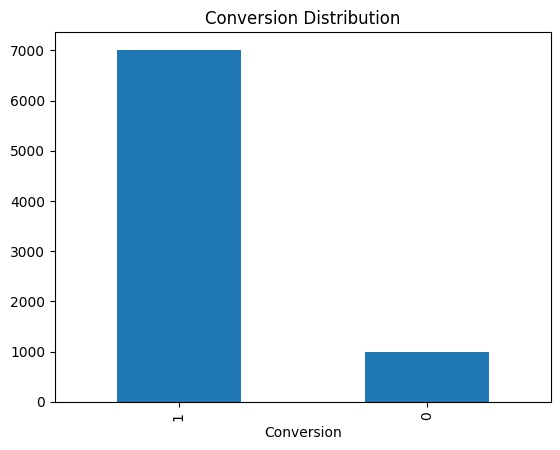

In [10]:
df['Conversion'].value_counts().plot(kind='bar')
plt.title('Conversion Distribution')
plt.show()

In [13]:
print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion'],
      dtype='object')


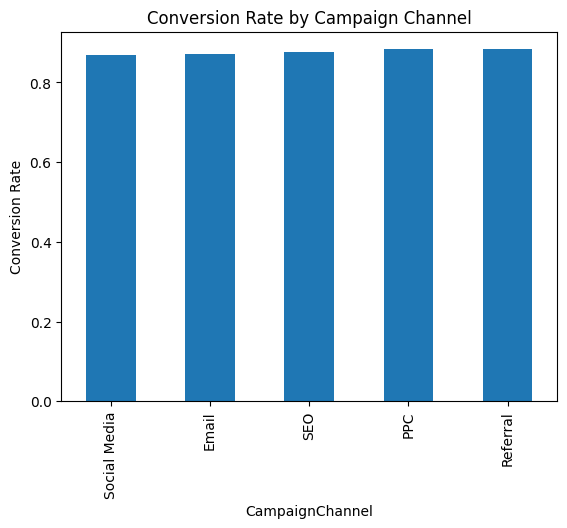

In [14]:
channel_conversion = df.groupby('CampaignChannel')['Conversion'].mean()

channel_conversion.sort_values().plot(kind='bar')
plt.title('Conversion Rate by Campaign Channel')
plt.ylabel('Conversion Rate')
plt.show()

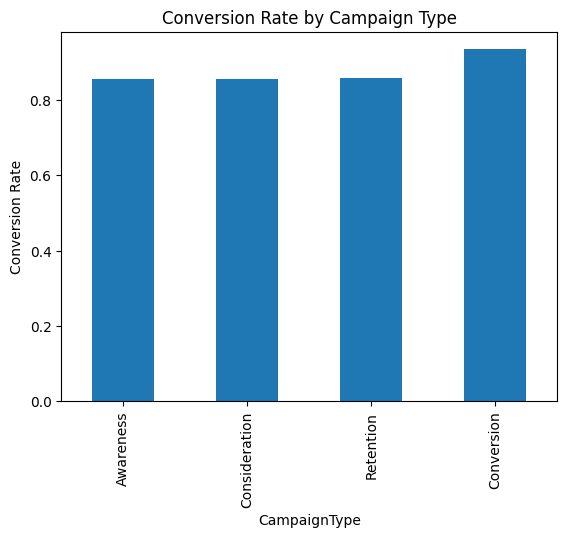

In [15]:
campaign_type = df.groupby('CampaignType')['Conversion'].mean()

campaign_type.sort_values().plot(kind='bar')
plt.title('Conversion Rate by Campaign Type')
plt.ylabel('Conversion Rate')
plt.show()

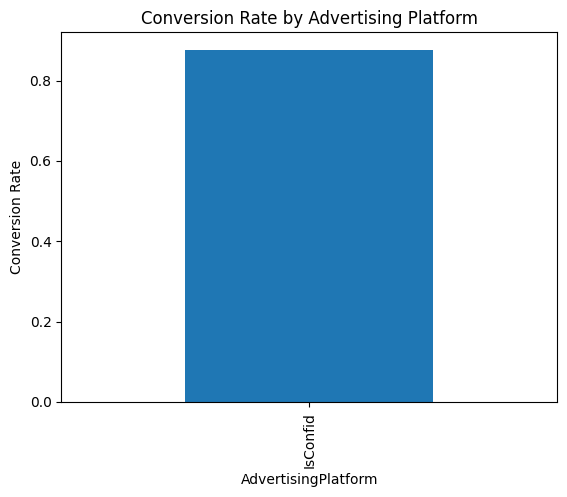

In [16]:
platform_conversion = df.groupby('AdvertisingPlatform')['Conversion'].mean()

platform_conversion.sort_values().plot(kind='bar')
plt.title('Conversion Rate by Advertising Platform')
plt.ylabel('Conversion Rate')
plt.show()

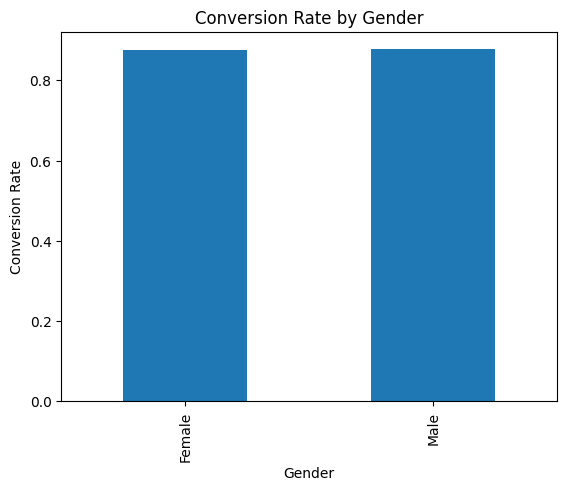

In [17]:
gender_conversion = df.groupby('Gender')['Conversion'].mean()

gender_conversion.plot(kind='bar')
plt.title('Conversion Rate by Gender')
plt.ylabel('Conversion Rate')
plt.show()

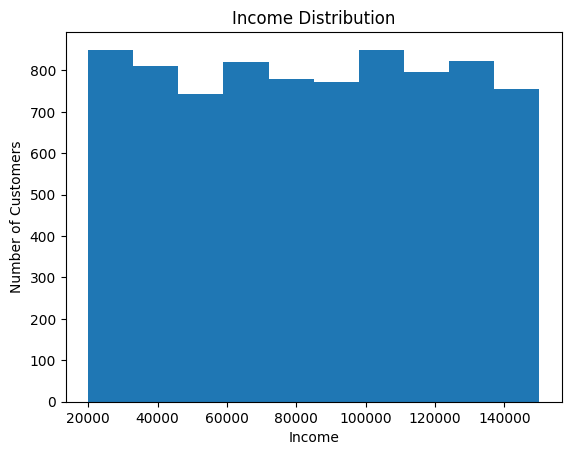

In [18]:
plt.hist(df['Income'])
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of Customers')
plt.show()

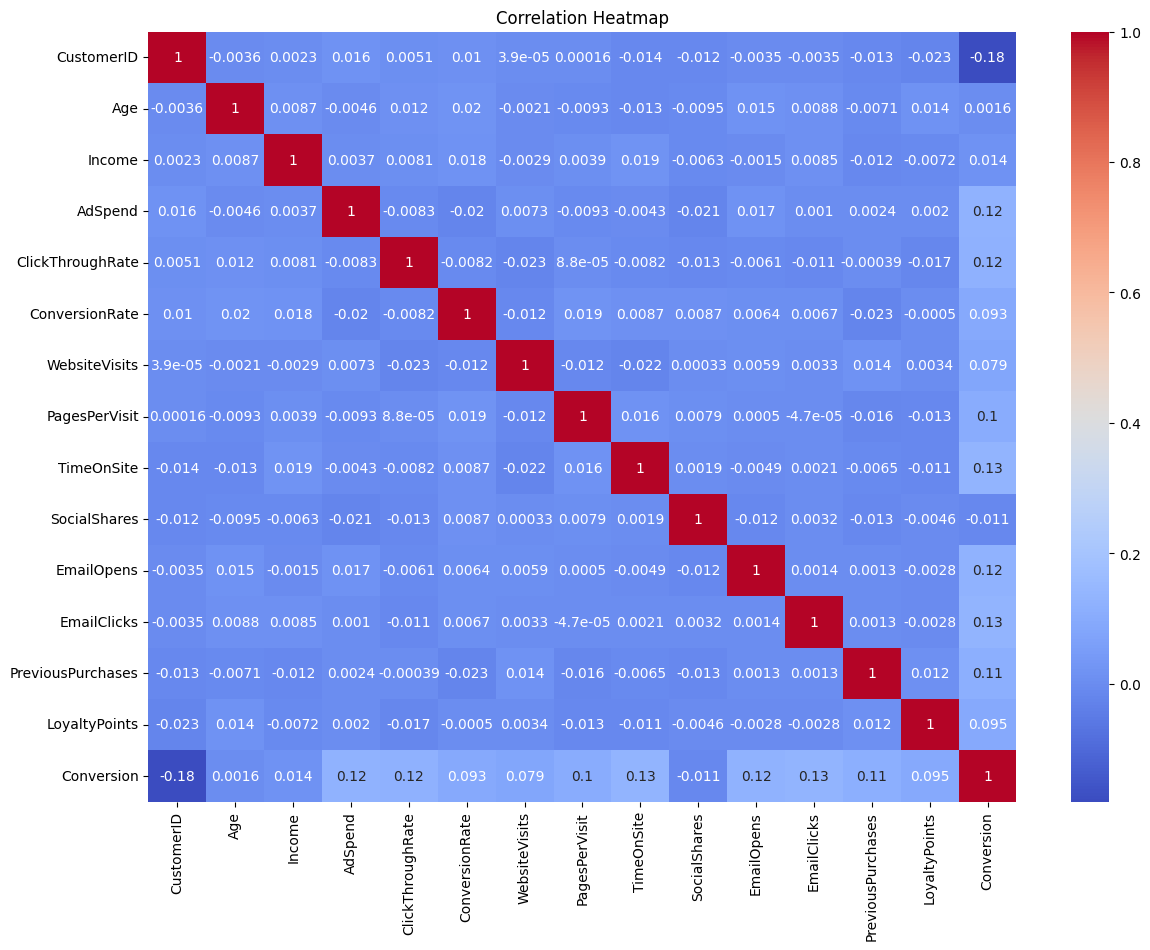

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

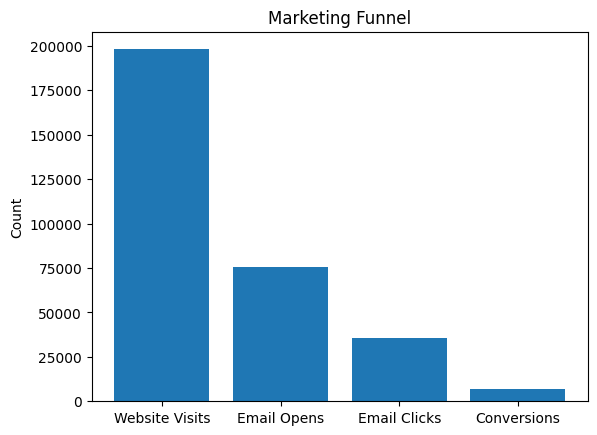

In [20]:
funnel = {
    'Website Visits': df['WebsiteVisits'].sum(),
    'Email Opens': df['EmailOpens'].sum(),
    'Email Clicks': df['EmailClicks'].sum(),
    'Conversions': df['Conversion'].sum()
}

plt.bar(funnel.keys(), funnel.values())
plt.title('Marketing Funnel')
plt.ylabel('Count')
plt.show()

In [21]:
print(channel_conversion.sort_values(ascending=False))

CampaignChannel
Referral        0.883072
PPC             0.882779
SEO             0.876774
Email           0.870263
Social Media    0.868334
Name: Conversion, dtype: float64


In [22]:
channel_conversion.sort_values(ascending=False)

,Conversion
CampaignChannel,
Referral,0.883072
PPC,0.882779
SEO,0.876774
Email,0.870263
Social Media,0.868334


In [23]:
platform_conversion.sort_values(ascending=False)

,Conversion
AdvertisingPlatform,
IsConfid,0.8765


In [24]:
df.groupby('Gender')['Conversion'].mean()

,Conversion
Gender,
Female,0.876214
Male,0.876938


In [25]:
df.groupby(pd.cut(df['Age'], bins=[18,25,35,45,55,65]))['Conversion'].mean()

/tmp/ipykernel_628/2102704660.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[18,25,35,45,55,65]))['Conversion'].mean()


,Conversion
Age,
"(18, 25]",0.860287
"(25, 35]",0.871222
"(35, 45]",0.901435
"(45, 55]",0.865885
"(55, 65]",0.881622


In [26]:
df.to_csv('cleaned_marketing_data.csv', index=False)

In [27]:
gender_conversion = df.groupby('Gender')['Conversion'].mean()
print(gender_conversion)

Gender
Female    0.876214
Male      0.876938
Name: Conversion, dtype: float64


In [28]:
age_conversion = df.groupby(
    pd.cut(df['Age'], bins=[18,25,35,45,55,65])
)['Conversion'].mean()

print(age_conversion)

Age
(18, 25]    0.860287
(25, 35]    0.871222
(35, 45]    0.901435
(45, 55]    0.865885
(55, 65]    0.881622
Name: Conversion, dtype: float64


/tmp/ipykernel_628/4051459516.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_conversion = df.groupby(


In [29]:
purchase_conversion = df.groupby(
    pd.cut(df['PreviousPurchases'], bins=5)
)['Conversion'].mean()

print(purchase_conversion)

PreviousPurchases
(-0.009, 1.8]    0.764093
(1.8, 3.6]       0.907210
(3.6, 5.4]       0.910533
(5.4, 7.2]       0.905815
(7.2, 9.0]       0.897833
Name: Conversion, dtype: float64


/tmp/ipykernel_628/2206065066.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purchase_conversion = df.groupby(


In [31]:
loyalty_conversion = df.groupby(
    pd.cut(df['LoyaltyPoints'], bins=5)
)['Conversion'].mean()

print(loyalty_conversion)

LoyaltyPoints
(-4.999, 999.8]     0.789507
(999.8, 1999.6]     0.895320
(1999.6, 2999.4]    0.890319
(2999.4, 3999.2]    0.904353
(3999.2, 4999.0]    0.902025
Name: Conversion, dtype: float64


/tmp/ipykernel_628/3292346895.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loyalty_conversion = df.groupby(


In [32]:
df.to_csv('cleaned_marketing_data.csv', index=False)